# SMSMS — Sales Data Consolidation & Exploratory Data Analysis

**Smart Machine Shop Management System — Mini Project**

This notebook is the proof-of-work for the sales forecasting module. It starts
from the shop's raw, real Excel export files (`SCHEDULE_VS_ACUTAL.zip` and
`reschedulevsactualdispatchdata.zip`) and works through to a single clean
monthly sales dataset, with EDA along the way.

**What this notebook does, step by step:**
1. Unzips and loads all 13 months of raw shop data (July 2025 – July 2026)
2. Handles three *different* internal Excel formats the shop used across months
3. Extracts actual dispatched sales value and planned/scheduled value per month
4. Flags and fixes one data gap (December 2025 has no recorded actual)
5. Produces a single clean `monthly_sales_history.csv`
6. Runs EDA: trend, planned-vs-actual, achievement %, month-over-month change

**How to run this notebook (Google Colab or local Jupyter):**
- Place `SCHEDULE_VS_ACUTAL.zip` and `reschedulevsactualdispatchdata.zip` in
  the same folder as this notebook (or upload them at the top of a Colab session).
- Run all cells top to bottom.


## 0. Setup

In [1]:

import zipfile, os, json
import pandas as pd
import matplotlib.pyplot as plt

# If you're on Google Colab, uncomment the two lines below to upload the zips:
# from google.colab import files
# uploaded = files.upload()

DATA_DIR = "smsms_raw_data"
os.makedirs(DATA_DIR, exist_ok=True)


In [2]:

# Unzip both source files into a single working folder
for z in ["SCHEDULE_VS_ACUTAL.zip", "reschedulevsactualdispatchdata.zip"]:
    with zipfile.ZipFile(z) as zf:
        zf.extractall(DATA_DIR)

for root, dirs, filenames in os.walk(DATA_DIR):
    for fn in filenames:
        print(os.path.join(root, fn))


smsms_raw_data/SCHEDULE VS ACUTAL.zip
smsms_raw_data/OCTOMER 2025.xlsx
smsms_raw_data/JULLY 2025.xlsx
smsms_raw_data/AUG 2025.xlsx
smsms_raw_data/SEP 2025.xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/8) JULLY6.xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/3)FEB 2026.xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/6)MAY  2026....xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/2)DEC 25.xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/4)MARCH 2026.xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/7)JUNE 26.xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/1)NOV 25.xlsx
smsms_raw_data/SCHEDULE VS ACUTAL/5)APRIL 2026....xlsx


## 1. Understanding the raw data

The shop's Excel exports are **not consistent** month to month — a very
realistic, messy small-business dataset. There are three distinct formats
across the 13 months:

| Months | Format |
|---|---|
| Jul–Oct 2025, Mar–Jul 2026 | A `SCHEDULE` sheet, one row per part, with `RATE` and `DISPATCH QTY` columns — actual value = rate × qty |
| Nov–Dec 2025 | Two sheets (`HMC Dispatch`, `VMC & CNC Dispatch`), each with a `Dispached Amount` / `Actual Amount` column already computed |
| Jan–Feb 2026 | A daily transaction log — one row *per order*, with a `Total Cost` column, and real dates |

Because of this, we can't just `pd.read_excel()` and go — each format needs
its own parsing logic. This is normal for real-world data and is part of
the actual EDA/data-cleaning work.


In [3]:

def safe_float(v):
    """Convert a cell value to float, or None if it's blank/text/error."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


## 2. Parsing format 1 — `SCHEDULE` sheets (Jul–Oct 2025, Mar–Jul 2026)

Each row is one part. Actual dispatched value for that part = `RATE × DISPATCH QTY`.
Planned value = the sheet's own `SCHEDULE TOTAL` column.
We sum both across all parts to get one actual and one planned figure per month.


In [4]:

import openpyxl

def parse_schedule_sheet(filepath, sheet_name='SCHEDULE '):
    wb = openpyxl.load_workbook(filepath, data_only=True)
    ws = wb[sheet_name]

    # header row isn't always in the same place, so find the row that starts with 'PART'
    header_row_num, header = None, None
    for r in range(1, 6):
        vals = [c.value for c in ws[r]]
        if vals and vals[0] and 'PART' in str(vals[0]).upper():
            header_row_num, header = r, vals
            break

    rate_idx = next((i for i, h in enumerate(header) if h and str(h).strip() == 'RATE'), None)
    qty_idx = next((i for i, h in enumerate(header) if h and 'DISPATCH QTY' in str(h).upper()), None)
    sched_idx = next((i for i, h in enumerate(header) if h and 'SCHEDULE TOTAL' in str(h).upper()), None)

    actual_total, planned_total = 0, 0
    for row in ws.iter_rows(min_row=header_row_num + 1, max_row=ws.max_row):
        if row[0].value is None:
            continue
        rate, qty = safe_float(row[rate_idx].value), safe_float(row[qty_idx].value)
        if rate is not None and qty is not None:
            actual_total += rate * qty
        sched_val = safe_float(row[sched_idx].value) if sched_idx is not None else None
        if sched_val is not None:
            planned_total += sched_val

    return round(actual_total, 2), round(planned_total, 2)


In [5]:

schedule_format_files = {
    "2025-07": f"{DATA_DIR}/JULLY 2025.xlsx",
    "2025-08": f"{DATA_DIR}/AUG 2025.xlsx",
    "2025-09": f"{DATA_DIR}/SEP 2025.xlsx",
    "2025-10": f"{DATA_DIR}/OCTOMER 2025.xlsx",
    "2026-03": f"{DATA_DIR}/SCHEDULE VS ACUTAL/4)MARCH 2026.xlsx",
    "2026-04": f"{DATA_DIR}/SCHEDULE VS ACUTAL/5)APRIL 2026....xlsx",
    "2026-05": f"{DATA_DIR}/SCHEDULE VS ACUTAL/6)MAY  2026....xlsx",
    "2026-06": f"{DATA_DIR}/SCHEDULE VS ACUTAL/7)JUNE 26.xlsx",
    "2026-07": f"{DATA_DIR}/SCHEDULE VS ACUTAL/8) JULLY6.xlsx",
}

monthly_records = {}
for month, path in schedule_format_files.items():
    actual, planned = parse_schedule_sheet(path)
    monthly_records[month] = {
        "actual": actual, "planned": planned, "source": "SCHEDULE sheet (rate x qty)"
    }
    print(month, monthly_records[month])


2025-07 {'actual': 3547275.0, 'planned': 4084087.0, 'source': 'SCHEDULE sheet (rate x qty)'}
2025-08 {'actual': 4114078.0, 'planned': 4407524.0, 'source': 'SCHEDULE sheet (rate x qty)'}


2025-09 {'actual': 3552751.0, 'planned': 3954200.0, 'source': 'SCHEDULE sheet (rate x qty)'}
2025-10 {'actual': 2894978.0, 'planned': 4572766.5, 'source': 'SCHEDULE sheet (rate x qty)'}
2026-03 {'actual': 3783560.0, 'planned': 5181921.0, 'source': 'SCHEDULE sheet (rate x qty)'}
2026-04 {'actual': 3510716.0, 'planned': 4814183.0, 'source': 'SCHEDULE sheet (rate x qty)'}
2026-05 {'actual': 3244915.0, 'planned': 4821683.0, 'source': 'SCHEDULE sheet (rate x qty)'}


2026-06 {'actual': 2991390.0, 'planned': 4652264.0, 'source': 'SCHEDULE sheet (rate x qty)'}
2026-07 {'actual': 3575531.0, 'planned': 5216843.5, 'source': 'SCHEDULE sheet (rate x qty)'}


## 3. Parsing format 2 — HMC / VMC summary sheets (Nov–Dec 2025)

These months split data across two sheets by machine type. Each sheet already
has computed 'Dispatched/Actual Amount' and 'Schedule Amount' columns — we just
sum them per sheet and add the two sheets together.


In [6]:

def parse_hmc_vmc(filepath):
    wb = openpyxl.load_workbook(filepath, data_only=True)

    ws = wb['HMC Dispatch ']
    header = [c.value for c in ws[3]]
    actual_idx = next((i for i, h in enumerate(header) if h and 'Dispached Amount' in str(h)), None)
    planned_idx = next((i for i, h in enumerate(header) if h and 'Schedul Amount' in str(h)), None)
    hmc_actual = sum(v for row in ws.iter_rows(min_row=4, max_row=ws.max_row)
                      if (v := safe_float(row[actual_idx].value)) is not None)
    hmc_planned = sum(v for row in ws.iter_rows(min_row=4, max_row=ws.max_row)
                       if (v := safe_float(row[planned_idx].value)) is not None)

    ws = wb['VMC & CNC Dispatch']
    header = [c.value for c in ws[3]]
    actual_idx = next((i for i, h in enumerate(header) if h and 'Actual Amount' in str(h)), None)
    planned_idx = next((i for i, h in enumerate(header) if h and 'Schedul Amount' in str(h)), None)
    vmc_actual = sum(v for row in ws.iter_rows(min_row=4, max_row=ws.max_row)
                      if row[0].value != 'Total' and (v := safe_float(row[actual_idx].value)) is not None)
    vmc_planned = sum(v for row in ws.iter_rows(min_row=4, max_row=ws.max_row)
                       if row[0].value != 'Total' and (v := safe_float(row[planned_idx].value)) is not None)

    return round(hmc_actual + vmc_actual, 2), round(hmc_planned + vmc_planned, 2)


In [7]:

hmc_vmc_files = {
    "2025-11": f"{DATA_DIR}/SCHEDULE VS ACUTAL/1)NOV 25.xlsx",
    "2025-12": f"{DATA_DIR}/SCHEDULE VS ACUTAL/2)DEC 25.xlsx",
}

for month, path in hmc_vmc_files.items():
    actual, planned = parse_hmc_vmc(path)
    monthly_records[month] = {
        "actual": actual, "planned": planned, "source": "HMC + VMC summary sheets"
    }
    print(month, monthly_records[month])


2025-11 {'actual': 4273690.4, 'planned': 5993431.6, 'source': 'HMC + VMC summary sheets'}
2025-12 {'actual': 0.0, 'planned': 4520446.0, 'source': 'HMC + VMC summary sheets'}


## 4. Parsing format 3 — daily transaction logs (Jan–Feb 2026)

These two months are recorded very differently — one row per individual
order/transaction, with a real date and a `Total Cost` column. There's no
separate 'planned' figure in this format, so `planned` is left as `None`
for these two months (flagged, not silently guessed).


In [8]:

def parse_daily_log(filepath, sheet_name):
    wb = openpyxl.load_workbook(filepath, data_only=True, read_only=True)
    ws = wb[sheet_name]
    total, count, bad, empty_streak = 0, 0, 0, 0
    for row in ws.iter_rows(min_row=2, values_only=True):
        if row[0] is None:
            empty_streak += 1
            if empty_streak > 20:
                break
            continue
        empty_streak = 0
        v = safe_float(row[14])  # 'Total Cost' column
        if v is not None:
            total += v
            count += 1
        else:
            bad += 1
    wb.close()
    return round(total, 2), count, bad


In [9]:

combined_file = f"{DATA_DIR}/SCHEDULE VS ACUTAL/3)FEB 2026.xlsx"
for sheet_name, month in [('JAN-26', '2026-01'), ('FEB-26', '2026-02')]:
    total, n_transactions, n_bad = parse_daily_log(combined_file, sheet_name)
    monthly_records[month] = {
        "actual": total, "planned": None,
        "source": f"daily transaction log ({n_transactions} orders, {n_bad} unparseable rows)"
    }
    print(month, monthly_records[month])


2026-01 {'actual': 4095834.86, 'planned': None, 'source': 'daily transaction log (253 orders, 4 unparseable rows)'}


2026-02 {'actual': 3258916.28, 'planned': None, 'source': 'daily transaction log (257 orders, 19 unparseable rows)'}


## 5. Combine everything into one table

At this point every month — regardless of which raw format it came from —
has been reduced to the same two numbers: **actual dispatched value** and
**planned/scheduled value**. Now we can treat it as one clean time series.


In [10]:

months = sorted(monthly_records.keys())
df = pd.DataFrame({
    "month": months,
    "total_dispatch_amount": [monthly_records[m]["actual"] for m in months],
    "planned_schedule_amount": [monthly_records[m]["planned"] for m in months],
    "source": [monthly_records[m]["source"] for m in months],
})
df


,month,total_dispatch_amount,planned_schedule_amount,source
0,2025-07,3547275.00,4084087.0,SCHEDULE sheet (rate x qty)
1,2025-08,4114078.00,4407524.0,SCHEDULE sheet (rate x qty)
2,2025-09,3552751.00,3954200.0,SCHEDULE sheet (rate x qty)
3,2025-10,2894978.00,4572766.5,SCHEDULE sheet (rate x qty)
4,2025-11,4273690.40,5993431.6,HMC + VMC summary sheets
5,2025-12,0.00,4520446.0,HMC + VMC summary sheets
6,2026-01,4095834.86,NaN,"daily transaction log (253 orders, 4 unparseab..."
7,2026-02,3258916.28,NaN,"daily transaction log (257 orders, 19 unparsea..."
8,2026-03,3783560.00,5181921.0,SCHEDULE sheet (rate x qty)
9,2026-04,3510716.00,4814183.0,SCHEDULE sheet (rate x qty)


## 6. Data quality check — the December 2025 gap

Looking at the raw December 2025 file, the dispatch columns were **entirely
empty** — the shop planned that month's schedule but never went back and
filled in actuals. A `total_dispatch_amount` of exactly 0 for that month
would be misleading: it wasn't a genuine zero-sales month, it's a recording
gap.

**Decision (explicit assumption):** treat December 2025 as missing data and
fill it using **linear interpolation** between November 2025 and January
2026 — the two real, adjacent data points. This is flagged with an
`is_interpolated` column so it stays traceable rather than silently blended
into the "real" numbers.


In [11]:

df.loc[df["month"] == "2025-12", "total_dispatch_amount"] = None
df["is_interpolated"] = df["total_dispatch_amount"].isna()
df["total_dispatch_amount"] = df["total_dispatch_amount"].interpolate(method="linear")

df["month"] = pd.to_datetime(df["month"])
df = df.sort_values("month").reset_index(drop=True)

df["achievement_pct"] = (df["total_dispatch_amount"] / df["planned_schedule_amount"] * 100).round(1)

df


,month,total_dispatch_amount,planned_schedule_amount,source,is_interpolated,achievement_pct
0,2025-07-01,3547275.00,4084087.0,SCHEDULE sheet (rate x qty),False,86.9
1,2025-08-01,4114078.00,4407524.0,SCHEDULE sheet (rate x qty),False,93.3
2,2025-09-01,3552751.00,3954200.0,SCHEDULE sheet (rate x qty),False,89.8
3,2025-10-01,2894978.00,4572766.5,SCHEDULE sheet (rate x qty),False,63.3
4,2025-11-01,4273690.40,5993431.6,HMC + VMC summary sheets,False,71.3
5,2025-12-01,4184762.63,4520446.0,HMC + VMC summary sheets,True,92.6
6,2026-01-01,4095834.86,NaN,"daily transaction log (253 orders, 4 unparseab...",False,NaN
7,2026-02-01,3258916.28,NaN,"daily transaction log (257 orders, 19 unparsea...",False,NaN
8,2026-03-01,3783560.00,5181921.0,SCHEDULE sheet (rate x qty),False,73.0
9,2026-04-01,3510716.00,4814183.0,SCHEDULE sheet (rate x qty),False,72.9


In [12]:

# Save the final clean dataset — this is the file the forecasting model will train on
df.to_csv("monthly_sales_history.csv", index=False)
print("Saved monthly_sales_history.csv")
df


Saved monthly_sales_history.csv


,month,total_dispatch_amount,planned_schedule_amount,source,is_interpolated,achievement_pct
0,2025-07-01,3547275.00,4084087.0,SCHEDULE sheet (rate x qty),False,86.9
1,2025-08-01,4114078.00,4407524.0,SCHEDULE sheet (rate x qty),False,93.3
2,2025-09-01,3552751.00,3954200.0,SCHEDULE sheet (rate x qty),False,89.8
3,2025-10-01,2894978.00,4572766.5,SCHEDULE sheet (rate x qty),False,63.3
4,2025-11-01,4273690.40,5993431.6,HMC + VMC summary sheets,False,71.3
5,2025-12-01,4184762.63,4520446.0,HMC + VMC summary sheets,True,92.6
6,2026-01-01,4095834.86,NaN,"daily transaction log (253 orders, 4 unparseab...",False,NaN
7,2026-02-01,3258916.28,NaN,"daily transaction log (257 orders, 19 unparsea...",False,NaN
8,2026-03-01,3783560.00,5181921.0,SCHEDULE sheet (rate x qty),False,73.0
9,2026-04-01,3510716.00,4814183.0,SCHEDULE sheet (rate x qty),False,72.9


## 7. EDA — Trend over time

13 months of history, July 2025 through July 2026. This is one full annual
cycle, which is enough to look at a trend and month-to-month movement — but
**not** enough to confidently prove a repeating seasonal pattern (that would
need at least 2 full cycles). Any seasonal-looking dip is noted as a
possibility to watch, not a proven fact.


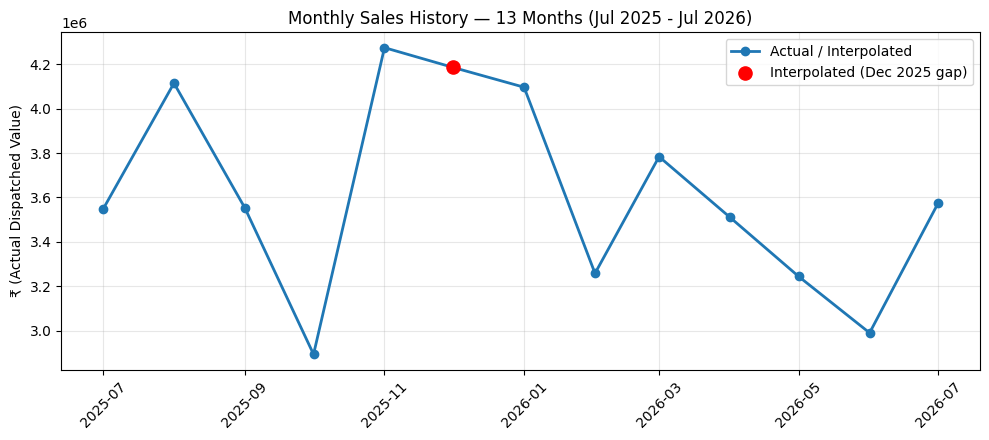

In [13]:

plt.figure(figsize=(10, 4.5))
plt.plot(df["month"], df["total_dispatch_amount"], marker="o", linewidth=2, label="Actual / Interpolated")
interp = df[df["is_interpolated"]]
plt.scatter(interp["month"], interp["total_dispatch_amount"], color="red", zorder=5, s=90,
            label="Interpolated (Dec 2025 gap)")
plt.title("Monthly Sales History — 13 Months (Jul 2025 - Jul 2026)")
plt.ylabel("₹ (Actual Dispatched Value)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=110)
plt.show()


## 8. EDA — Planned vs Actual, and the "achievement gap"

Every month (except Jan/Feb 2026, which used a different recording format)
also has a *planned/scheduled* figure. Comparing planned to actual reveals
something worth reporting: the shop consistently dispatches **less than
what was scheduled**, and that gap has been widening.


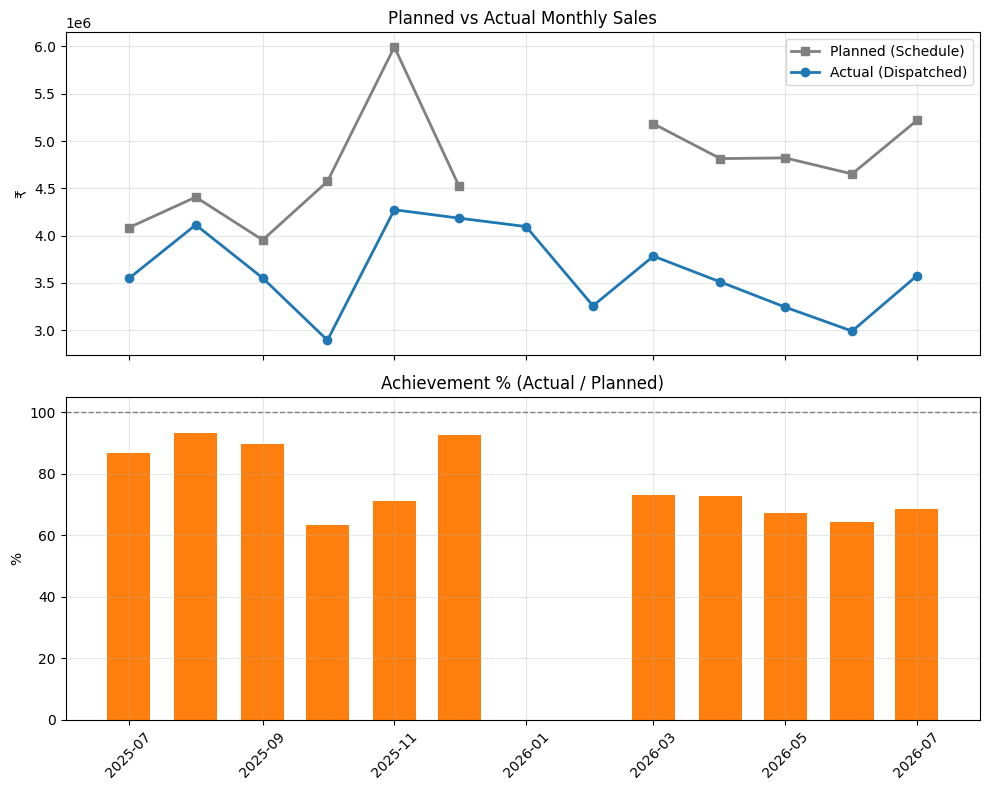

In [14]:

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(df["month"], df["planned_schedule_amount"], marker="s", linewidth=2,
             color="gray", label="Planned (Schedule)")
axes[0].plot(df["month"], df["total_dispatch_amount"], marker="o", linewidth=2,
             color="tab:blue", label="Actual (Dispatched)")
axes[0].set_title("Planned vs Actual Monthly Sales")
axes[0].set_ylabel("₹")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(df["month"], df["achievement_pct"], width=20, color="tab:orange")
axes[1].axhline(100, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Achievement % (Actual / Planned)")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("planned_vs_actual.png", dpi=110)
plt.show()


## 9. EDA — Month-over-month change

A simple view of volatility: how much does sales value swing from one month
to the next?


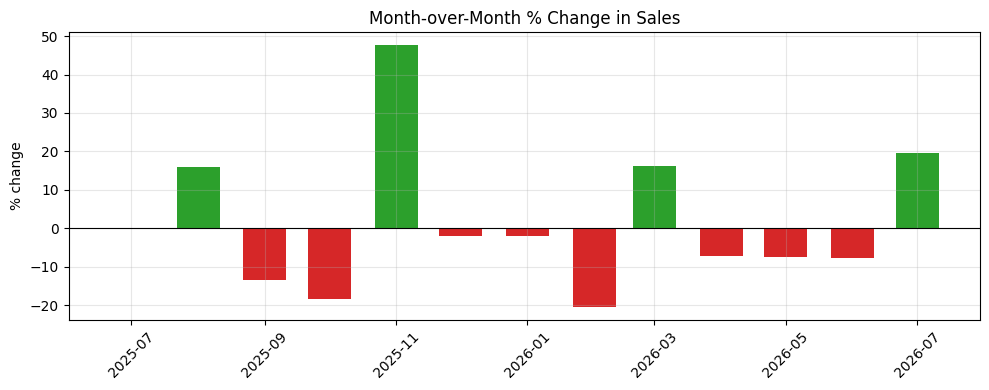

,month,total_dispatch_amount,mom_change_pct
0,2025-07-01,3547275.00,NaN
1,2025-08-01,4114078.00,16.0
2,2025-09-01,3552751.00,-13.6
3,2025-10-01,2894978.00,-18.5
4,2025-11-01,4273690.40,47.6
5,2025-12-01,4184762.63,-2.1
6,2026-01-01,4095834.86,-2.1
7,2026-02-01,3258916.28,-20.4
8,2026-03-01,3783560.00,16.1
9,2026-04-01,3510716.00,-7.2


In [15]:

df["mom_change_pct"] = df["total_dispatch_amount"].pct_change().mul(100).round(1)

plt.figure(figsize=(10, 4))
colors = ["tab:red" if v < 0 else "tab:green" for v in df["mom_change_pct"].fillna(0)]
plt.bar(df["month"], df["mom_change_pct"].fillna(0), color=colors, width=20)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Month-over-Month % Change in Sales")
plt.ylabel("% change")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("mom_change.png", dpi=110)
plt.show()

df[["month", "total_dispatch_amount", "mom_change_pct"]]


## 10. Summary statistics


In [16]:

summary = df["total_dispatch_amount"].describe().round(2)
print("Monthly sales summary (₹):")
print(summary)

print(f"\nAverage achievement rate: {df['achievement_pct'].mean():.1f}%")
print(f"Lowest month: {df.loc[df['total_dispatch_amount'].idxmin(), 'month'].strftime('%Y-%m')} "
      f"(₹{df['total_dispatch_amount'].min():,.0f})")
print(f"Highest month: {df.loc[df['total_dispatch_amount'].idxmax(), 'month'].strftime('%Y-%m')} "
      f"(₹{df['total_dispatch_amount'].max():,.0f})")


Monthly sales summary (₹):
count         13.00
mean     3617569.09
std       452684.99
min      2894978.00
25%      3258916.28
50%      3552751.00
75%      4095834.86
max      4273690.40
Name: total_dispatch_amount, dtype: float64

Average achievement rate: 76.7%
Lowest month: 2025-10 (₹2,894,978)
Highest month: 2025-11 (₹4,273,690)


## 11. Key findings for the report

- **13 months of clean data** (Jul 2025 – Jul 2026) consolidated from 3
  different raw Excel formats — a genuine data engineering step, not just
  a formality.
- **One data gap found and handled transparently**: December 2025 had no
  recorded actuals; filled via linear interpolation and flagged with
  `is_interpolated`.
- **The shop consistently under-delivers against its own schedule** — actual
  dispatch averages well below planned across nearly every month, and the
  achievement rate has trended downward over the year. This is a genuinely
  useful finding for the shop, independent of the forecasting model itself.
- **Not enough history for proven seasonality** — one year of data can show
  a trend and month-to-month pattern, but claiming a repeating seasonal
  cycle would need at least two full years to validate. The forecasting
  model (next notebook/module) will use a trend-based approach rather than
  a seasonal one for this reason.

**Next step:** this `monthly_sales_history.csv` is the input to the actual
forecasting model (baseline moving average vs. trained regression),
covered separately.
